In [2]:
# ── 셀 1: 데이터 파일 확인 + 스테이션 통과 기록 만들기 ───────
# train_numeric.csv는 약 2GB → 한 번에 읽지 않고 5만 행씩 잘라서 읽음
# 각 부품이 "어느 스테이션을 지나갔는지(측정값이 있는지)"만 뽑아 작게 저장
import os, glob, time
import numpy as np
import pandas as pd

def find_csv(name):
    # 압축 해제 방식에 따라 폴더 안에 들어가 있을 수도 있어서 둘 다 찾음
    hits = [p for p in glob.glob(f'**/{name}', recursive=True) if os.path.isfile(p)]
    if not hits:
        raise FileNotFoundError(f'{name} 파일을 찾을 수 없음')
    return hits[0]

NUM_PATH = find_csv('train_numeric.csv')
DATE_PATH = find_csv('train_date.csv')
print('numeric:', NUM_PATH, f'{os.path.getsize(NUM_PATH)/1e9:.2f}GB')
print('date   :', DATE_PATH, f'{os.path.getsize(DATE_PATH)/1e9:.2f}GB')

# 열 이름 구조: L0_S5_F114 = 라인 0 / 스테이션 5 / 측정값 114
cols = pd.read_csv(NUM_PATH, nrows=0).columns.tolist()
feat_cols = [c for c in cols if c not in ('Id', 'Response')]
station_of = {c: '_'.join(c.split('_')[:2]) for c in feat_cols}          # L0_S5
stations = sorted(set(station_of.values()), key=lambda s: (int(s.split('_')[0][1:]), int(s.split('_')[1][1:])))
print(f'측정값 열 {len(feat_cols)}개, 스테이션 {len(stations)}개')

PASS_PATH = 'station_pass.pkl'
if os.path.exists(PASS_PATH):
    passed = pd.read_pickle(PASS_PATH)
    print('저장된 통과 기록 불러옴')
else:
    t0 = time.time()
    parts = []
    reader = pd.read_csv(NUM_PATH, chunksize=50000, dtype=np.float32)
    for i, chunk in enumerate(reader):
        has_value = chunk[feat_cols].notna()
        # 스테이션 안의 측정값 중 하나라도 있으면 그 스테이션을 지나간 것으로 봄
        st = has_value.T.groupby(station_of).any().T.astype(np.uint8)[stations]
        st.insert(0, 'Id', chunk['Id'].astype(np.int64).values)
        st['Response'] = chunk['Response'].astype(np.int8).values
        parts.append(st)
        if i % 4 == 0:
            print(f'  {(i+1)*50000:,}행 처리 ({time.time()-t0:.0f}초)')
    passed = pd.concat(parts, ignore_index=True)
    passed.to_pickle(PASS_PATH)
    print(f'완료: {time.time()-t0:.0f}초')

print(f'\n부품 수: {len(passed):,}개')
print(f'불량 부품: {passed["Response"].sum():,}개 (불량률 {passed["Response"].mean():.2%})')
print(f'메모리 사용: {passed.memory_usage().sum()/1e6:.0f}MB')

numeric: train_numeric.csv\train_numeric.csv 2.14GB
date   : train_date.csv\train_date.csv 2.89GB
측정값 열 968개, 스테이션 50개
저장된 통과 기록 불러옴

부품 수: 1,183,747개
불량 부품: 6,879개 (불량률 0.58%)
메모리 사용: 70MB


전체 불량률: 0.581%
평균보다 확실히 높은 스테이션: 5개 / 50개

  스테이션   통과 부품   불량   불량률    하한    상한 미통과 불량률 배수(통과/미통과)  평균보다 확실히 높음
L3_S32   24543 1106 4.51% 4.25% 4.77%   0.50%        9.0         True
L1_S24  183727 1521 0.83% 0.79% 0.87%   0.54%        1.5         True
L3_S38   27142  212 0.78% 0.68% 0.89%   0.58%        1.4         True
L2_S26  227011 1695 0.75% 0.71% 0.78%   0.54%        1.4         True
L2_S28    9583   67 0.70% 0.55% 0.89%   0.58%        1.2        False
L2_S27  120729  822 0.68% 0.64% 0.73%   0.57%        1.2         True
L3_S36  569032 3391 0.60% 0.58% 0.62%   0.57%        1.1        False
L3_S37 1120394 6556 0.59% 0.57% 0.60%   0.51%        1.1        False
L3_S30 1119811 6551 0.59% 0.57% 0.60%   0.51%        1.1        False
L3_S29 1119629 6546 0.58% 0.57% 0.60%   0.52%        1.1        False
L3_S35  552108 3177 0.58% 0.56% 0.60%   0.59%        1.0        False
L0_S21   81409  461 0.57% 0.52% 0.62%   0.58%        1.0        False


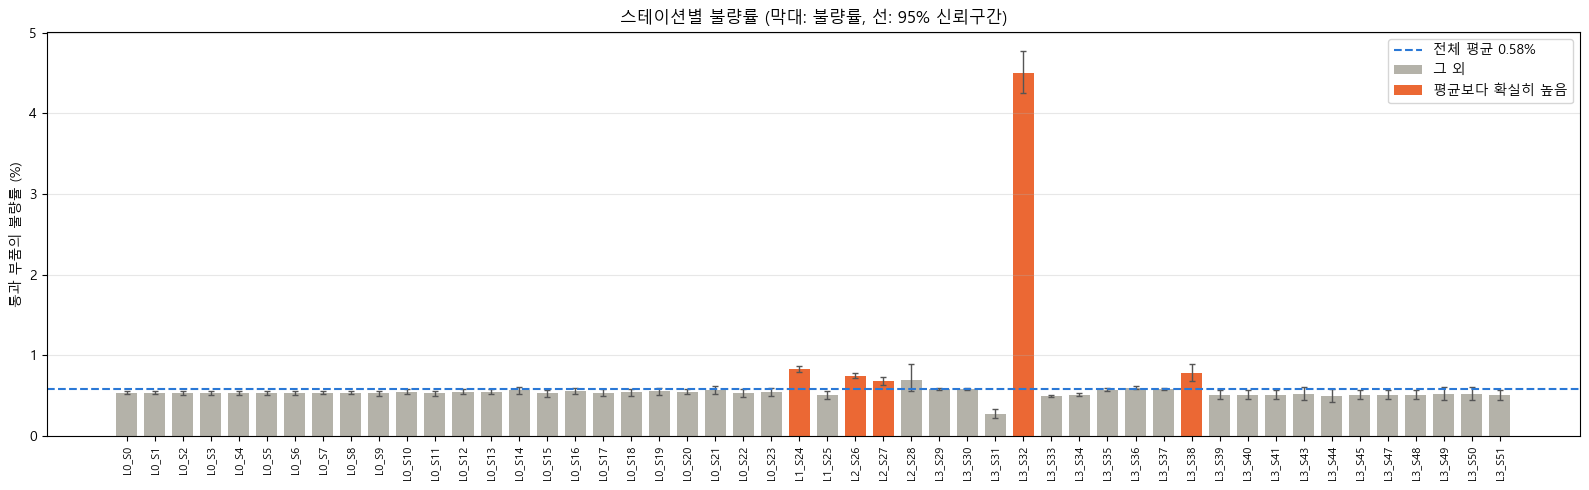

In [3]:
# ── 셀 2: 스테이션별 불량률 ─────────────────────────────
# 질문: 어느 스테이션을 지나간 부품에서 불량이 몰리는가?
# 비교 기준: 그 스테이션을 "지나간 부품" vs "안 지나간 부품"의 불량률
# 통과 부품이 적은 스테이션은 불량률이 우연히 튈 수 있음 → 95% 신뢰구간(Wilson)으로 확인
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

def wilson(fail, n, z=1.96):
    # 불량률의 95% 신뢰구간: 표본이 적을수록 구간이 넓어짐
    if n == 0:
        return np.nan, np.nan
    p = fail / n
    center = (p + z**2 / (2*n)) / (1 + z**2 / n)
    half = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / (1 + z**2 / n)
    return center - half, center + half

overall = passed['Response'].mean()
rows = []
for s in stations:
    on = passed[s] == 1
    n_on, f_on = int(on.sum()), int(passed.loc[on, 'Response'].sum())
    n_off, f_off = int((~on).sum()), int(passed.loc[~on, 'Response'].sum())
    lo, hi = wilson(f_on, n_on)
    rows.append({
        '스테이션': s, '통과 부품': n_on, '불량': f_on,
        '불량률': f_on / n_on if n_on else np.nan,
        '하한': lo, '상한': hi,
        '미통과 불량률': f_off / n_off if n_off else np.nan,
    })
st_stats = pd.DataFrame(rows)
st_stats['배수(통과/미통과)'] = st_stats['불량률'] / st_stats['미통과 불량률']
# 신뢰구간 하한조차 전체 평균보다 높으면 → 우연이 아니라 실제로 불량이 몰리는 스테이션
st_stats['평균보다 확실히 높음'] = st_stats['하한'] > overall

print(f'전체 불량률: {overall:.3%}')
print(f"평균보다 확실히 높은 스테이션: {st_stats['평균보다 확실히 높음'].sum()}개 / {len(st_stats)}개\n")
show = st_stats.sort_values('불량률', ascending=False).head(12)
print(show.to_string(index=False, formatters={
    '불량률': '{:.2%}'.format, '하한': '{:.2%}'.format, '상한': '{:.2%}'.format,
    '미통과 불량률': '{:.2%}'.format, '배수(통과/미통과)': '{:.1f}'.format}))

# 그래프: 스테이션 순서대로 불량률 + 신뢰구간, 확실히 높은 곳만 강조
fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(st_stats))
hot = st_stats['평균보다 확실히 높음'].values
for flag, color, name in [(False, '#b4b2a9', '그 외'), (True, '#eb6834', '평균보다 확실히 높음')]:
    m = hot == flag
    ax.bar(x[m], st_stats['불량률'][m] * 100, color=color, width=0.75, label=name)
    ax.errorbar(x[m], st_stats['불량률'][m] * 100,
                yerr=[(st_stats['불량률'] - st_stats['하한'])[m] * 100,
                      (st_stats['상한'] - st_stats['불량률'])[m] * 100],
                fmt='none', ecolor='#555555', elinewidth=1, capsize=2)
ax.axhline(overall * 100, color='#2a78d6', linewidth=1.5, linestyle='--', label=f'전체 평균 {overall:.2%}')
ax.set_xticks(x)
ax.set_xticklabels(st_stats['스테이션'], rotation=90, fontsize=8)
ax.set_ylabel('통과 부품의 불량률 (%)')
ax.set_title('스테이션별 불량률 (막대: 불량률, 선: 95% 신뢰구간)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ── 셀 3: 스테이션별 통과 시각 만들기 (train_date.csv) ─────
# train_date.csv는 각 측정이 "언제" 이뤄졌는지 기록 (약 2.9GB)
# 부품마다 스테이션별로 가장 이른 시각 하나만 남겨 작게 저장 → 공정 순서 분석에 사용
TIME_PATH = 'station_time.pkl'
if os.path.exists(TIME_PATH):
    st_time = pd.read_pickle(TIME_PATH)
    print('저장된 통과 시각 불러옴')
else:
    dcols = pd.read_csv(DATE_PATH, nrows=0).columns.tolist()
    date_feat = [c for c in dcols if c != 'Id']
    dstation_of = {c: '_'.join(c.split('_')[:2]) for c in date_feat}
    dstations = sorted(set(dstation_of.values()),
                       key=lambda s: (int(s.split('_')[0][1:]), int(s.split('_')[1][1:])))
    print(f'시각 열 {len(date_feat)}개, 스테이션 {len(dstations)}개')

    t0 = time.time()
    parts = []
    for i, chunk in enumerate(pd.read_csv(DATE_PATH, chunksize=50000, dtype=np.float32)):
        # 스테이션 안 여러 측정 시각 중 가장 이른 값 = 그 스테이션에 들어간 시각
        t = chunk[date_feat].T.groupby(dstation_of).min().T[dstations]
        t.insert(0, 'Id', chunk['Id'].astype(np.int64).values)
        parts.append(t)
        if i % 4 == 0:
            print(f'  {(i+1)*50000:,}행 처리 ({time.time()-t0:.0f}초)')
    st_time = pd.concat(parts, ignore_index=True)
    st_time.to_pickle(TIME_PATH)
    print(f'완료: {time.time()-t0:.0f}초')

# 셀 1의 통과 기록과 같은 부품 순서인지 확인
assert (st_time['Id'].values == passed['Id'].values).all(), '부품 순서가 다름'
print(st_time.shape, f'메모리 {st_time.memory_usage().sum()/1e6:.0f}MB')

저장된 통과 시각 불러옴
(1183747, 53) 메모리 256MB


In [5]:
# ── 셀 4: L3_S32는 불량을 만드는가, 문제 부품이 보내지는 곳인가 ──
# 가설 A: S32가 불량을 만든다 → S32는 정상 흐름 중간에 있고, 앞 경로와 무관하게 불량률이 높아야 함
# 가설 B: 문제 있는 부품이 S32로 보내진다(재작업·재검사) → S32 진입 순서가 튀거나, 앞 경로에 따라 불량률이 갈려야 함
TARGET = 'L3_S32'
tcols = [c for c in st_time.columns if c != 'Id']
T = st_time[tcols].values
j = tcols.index(TARGET)
on = ~np.isnan(T[:, j])                     # S32 통과 시각이 있는 부품
print(f'{TARGET} 시각 기록이 있는 부품: {on.sum():,}개')

T_on = T[on]
t_target = T_on[:, j][:, None]
diff = T_on - t_target                      # 다른 스테이션 시각 - S32 시각
diff[:, j] = np.nan

# ① S32 직전·직후 스테이션 (시각 기준 가장 가까운 앞/뒤)
before = np.where(diff < 0, diff, -np.inf)
after = np.where(diff > 0, diff, np.inf)
has_before = np.isfinite(before).any(axis=1)
has_after = np.isfinite(after).any(axis=1)
prev_st = np.where(has_before, np.array(tcols)[before.argmax(axis=1)], '(없음)')
next_st = np.where(has_after, np.array(tcols)[after.argmin(axis=1)], '(없음: 마지막)')
same_time = (diff == 0).any(axis=1)

print(f"\nS32가 그 부품의 마지막 스테이션인 비율: {(~has_after).mean():.1%}")
print(f"S32와 같은 시각으로 기록된 스테이션이 있는 비율: {same_time.mean():.1%}")
print('\nS32 직전 스테이션 상위 5개')
print(pd.Series(prev_st).value_counts().head(5).to_string())
print('\nS32 직후 스테이션 상위 5개')
print(pd.Series(next_st).value_counts().head(5).to_string())

# ② S32에 들어오기 전 어느 라인(L0/L1/L2)을 거쳤나 → 앞 경로별 불량률
resp = passed['Response'].values
line_cols = {L: [s for s in stations if s.startswith(L + '_')] for L in ['L0', 'L1', 'L2']}
via = pd.Series('기타', index=passed.index)
p1 = passed[line_cols['L1']].any(axis=1)
p2 = passed[line_cols['L2']].any(axis=1)
via[p1 & ~p2] = 'L1 경유'
via[p2 & ~p1] = 'L2 경유'
via[p1 & p2] = 'L1+L2 둘 다'
via[~p1 & ~p2] = 'L1·L2 안 거침'

s32_on = (passed[TARGET] == 1).values
comp = pd.DataFrame({
    '경로': via, 'S32 통과': np.where(s32_on, 'S32 통과', 'S32 미통과'), 'Response': resp})
table = comp.groupby(['경로', 'S32 통과'])['Response'].agg(['count', 'sum', 'mean']).unstack()
table.columns = [f'{a}_{b}' for a, b in table.columns]
table = table.rename(columns=lambda c: c.replace('count', '부품 수').replace('sum', '불량').replace('mean', '불량률'))
for c in table.columns:
    if c.startswith('불량률'):
        table[c] = (table[c] * 100).round(2).astype(str) + '%'
print('\n앞 경로별 불량률 (S32 통과 vs 미통과)')
print(table.to_string())

L3_S32 시각 기록이 있는 부품: 24,543개

S32가 그 부품의 마지막 스테이션인 비율: 4.4%
S32와 같은 시각으로 기록된 스테이션이 있는 비율: 30.4%

S32 직전 스테이션 상위 5개
L3_S29    12598
L3_S30    11351
L3_S31      584
L2_S27        5
L2_S26        3

S32 직후 스테이션 상위 5개
L3_S33       12273
L3_S34        3921
L3_S36        3531
L3_S35        2557
(없음: 마지막)     1088

앞 경로별 불량률 (S32 통과 vs 미통과)
            부품 수_S32 미통과  부품 수_S32 통과  불량_S32 미통과  불량_S32 통과 불량률_S32 미통과 불량률_S32 통과
경로                                                                                 
L1 경유              22223          445         192         14       0.86%      3.15%
L1+L2 둘 다         240141         4464        1374        360       0.57%      8.06%
L1·L2 안 거침        787148        16912        3486        612       0.44%      3.62%
L2 경유             109692         2722         721        120       0.66%      4.41%


비교할 측정값: 121개 (L3_S29, L3_S30)
읽기 완료: 22초
S30 통과 부품 중  S32로 감: 24,500개 / 안 감: 1,095,311개

|SMD| ≥ 0.5 (중간 이상 차이) 측정값: 0개 / 121개
|SMD| ≥ 0.2 (작은 차이 이상) 측정값: 0개 / 121개

차이가 큰 측정값 상위 10개
                SMD  |SMD|  누락률 차이
L3_S30_F3704  0.132  0.132   0.024
L3_S30_F3579  0.099  0.099   0.024
L3_S29_F3458  0.098  0.098  -0.000
L3_S29_F3351  0.098  0.098  -0.000
L3_S30_F3569  0.090  0.090   0.024
L3_S30_F3769 -0.081  0.081   0.000
L3_S30_F3744 -0.055  0.055   0.000
L3_S30_F3514  0.053  0.053   0.000
L3_S30_F3539  0.053  0.053   0.000
L3_S29_F3479 -0.047  0.047   0.011


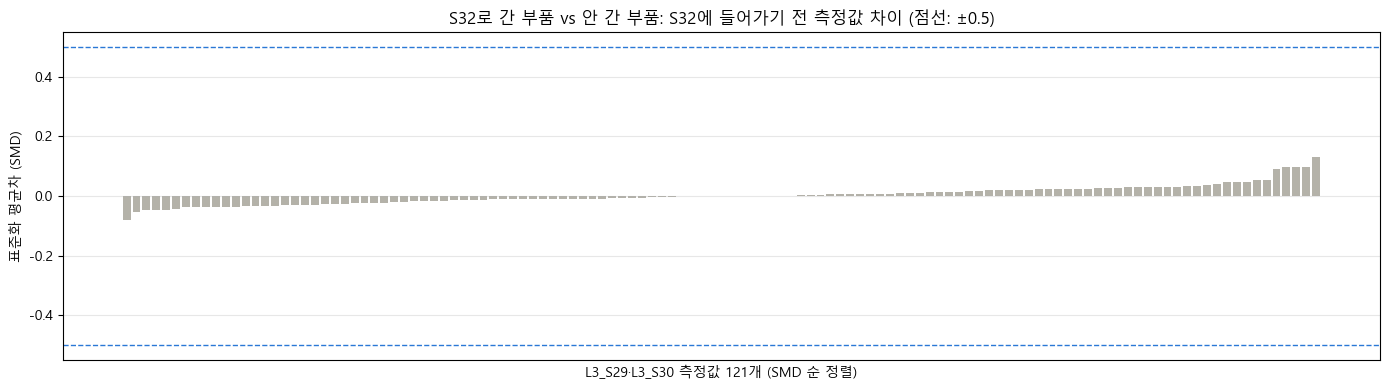

In [6]:
# ── 셀 5: S32로 가는 부품은 S32에 들어가기 "전부터" 달랐나 ──────
# 셀 4 결과: S32 바로 앞은 S29·S30
# S32로 갈 부품과 안 갈 부품을, 둘 다 거친 S29·S30의 측정값으로 비교
#  - 거의 같다 → 들어가기 전엔 평범했던 부품이 S32를 거치며 불량 → S32 자체 문제(가설 A)
#  - 이미 다르다 → S29·S30에서 이상한 부품을 S32로 보낸 것 → S32는 결과(가설 B)
UP = ['L3_S29', 'L3_S30']
up_cols = [c for c in feat_cols if station_of[c] in UP]
print(f'비교할 측정값: {len(up_cols)}개 ({", ".join(UP)})')

UP_PATH = 'upstream_s29_s30.pkl'
if os.path.exists(UP_PATH):
    up = pd.read_pickle(UP_PATH)
else:
    t0 = time.time()
    up = pd.concat(pd.read_csv(NUM_PATH, usecols=['Id'] + up_cols, chunksize=100000, dtype=np.float32),
                   ignore_index=True)
    up.to_pickle(UP_PATH)
    print(f'읽기 완료: {time.time()-t0:.0f}초')

# 비교 대상: S30을 지나간 부품만 (S32로 갈 기회가 있었던 부품끼리 비교)
base = (passed['L3_S30'] == 1).values
to32 = (passed[TARGET] == 1).values
g1, g0 = up.loc[base & to32, up_cols], up.loc[base & ~to32, up_cols]
print(f'S30 통과 부품 중  S32로 감: {len(g1):,}개 / 안 감: {len(g0):,}개')

# 표준화 평균차(SMD): 두 집단 평균 차이 ÷ 표준편차
# 표본 수와 상관없이 "차이의 크기"를 비교하는 지표. |SMD| 0.2 작음 / 0.5 중간 / 0.8 큼
m1, m0 = g1.mean(), g0.mean()
s = np.sqrt((g1.var() + g0.var()) / 2)
smd = ((m1 - m0) / s).replace([np.inf, -np.inf], np.nan)
miss_gap = g1.isna().mean() - g0.isna().mean()          # 측정 누락 비율 차이도 확인

res = pd.DataFrame({'SMD': smd, '|SMD|': smd.abs(), '누락률 차이': miss_gap}).dropna(subset=['SMD'])
print(f"\n|SMD| ≥ 0.5 (중간 이상 차이) 측정값: {(res['|SMD|'] >= 0.5).sum()}개 / {len(res)}개")
print(f"|SMD| ≥ 0.2 (작은 차이 이상) 측정값: {(res['|SMD|'] >= 0.2).sum()}개 / {len(res)}개")
print('\n차이가 큰 측정값 상위 10개')
print(res.sort_values('|SMD|', ascending=False).head(10).round(3).to_string())

# 그래프: 측정값별 SMD 분포
fig, ax = plt.subplots(figsize=(14, 4))
order = res.sort_values('SMD').index
colors = np.where(res.loc[order, '|SMD|'] >= 0.5, '#eb6834', '#b4b2a9')
ax.bar(range(len(order)), res.loc[order, 'SMD'], color=colors, width=0.8)
for y0 in (-0.5, 0.5):
    ax.axhline(y0, color='#2a78d6', linestyle='--', linewidth=1)
ax.set_xticks([])
ax.set_xlabel(f'{"·".join(UP)} 측정값 {len(res)}개 (SMD 순 정렬)')
ax.set_ylabel('표준화 평균차 (SMD)')
ax.set_title('S32로 간 부품 vs 안 간 부품: S32에 들어가기 전 측정값 차이 (점선: ±0.5)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ── 셀 6: 측정값 "조합"으로는 S32행을 예측할 수 있나 ──────────
# 셀 5는 측정값을 하나씩 비교 → 여러 값의 조합으로 S32에 보냈다면 놓칠 수 있음
# S29·S30 측정값 121개를 모두 넣어 "이 부품이 S32로 갈지" 예측해 봄
#  - AUC ≈ 0.5 : 동전 던지기 수준 → S32 투입이 S29·S30 측정값과 무관 → 가설 B(선별 투입) 근거 없음
#  - AUC가 높음 : 측정값 조합으로 S32행이 결정됨 → 가설 B 가능성 남음
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_route = up.loc[base, up_cols].values          # S30 통과 부품의 S29·S30 측정값 (결측 그대로)
y_route = to32[base].astype(int)                # S32로 갔으면 1

hgb = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, random_state=42)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
t0 = time.time()
auc = cross_val_score(hgb, X_route, y_route, cv=cv, scoring='roc_auc', n_jobs=1)
print(f'S32행 예측 AUC (3-fold): {auc.mean():.3f} ± {auc.std():.3f}  ({time.time()-t0:.0f}초)')
print('기준: 0.5 = 무작위, 0.7 이상 = 측정값으로 어느 정도 구분됨')

S32행 예측 AUC (3-fold): 0.584 ± 0.001  (32초)
기준: 0.5 = 무작위, 0.7 이상 = 측정값으로 어느 정도 구분됨


In [8]:
# ── 셀 7: 경로 정보가 불량 예측에 실제로 도움이 되나 ───────────
# 지금까지는 "통계"로 S32를 찾음 → 마지막으로 "모델"로 경로 정보의 가치를 검증
#  A: 측정값만 (968개)
#  B: 경로만 (스테이션 통과 여부 50개 + 거친 스테이션 수)
#  C: 측정값 + 경로
# 불량 0.58% → 정확도는 의미 없음(전부 양품이라 해도 99.4%) → PR-AUC로 평가 (SECOM과 같은 판단)
# 측정값 968개 × 118만 개는 메모리에 부담 → 30만 개 무작위 샘플 (불량 비율은 그대로 유지)
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold

SAMPLE_PATH = 'model_sample_300k.pkl'
rng = np.random.default_rng(42)
if os.path.exists(SAMPLE_PATH):
    sample = pd.read_pickle(SAMPLE_PATH)
else:
    keep_ids = set(rng.choice(passed['Id'].values, size=min(300000, len(passed)), replace=False))
    t0 = time.time()
    parts = []
    for chunk in pd.read_csv(NUM_PATH, chunksize=50000, dtype=np.float32):
        parts.append(chunk[chunk['Id'].astype(np.int64).isin(keep_ids)])
    sample = pd.concat(parts, ignore_index=True)
    sample['Id'] = sample['Id'].astype(np.int64)
    sample.to_pickle(SAMPLE_PATH)
    print(f'샘플 추출: {time.time()-t0:.0f}초')

path_feat = passed.set_index('Id').loc[sample['Id'], stations].reset_index(drop=True)
path_feat['n_stations'] = path_feat.sum(axis=1)
y_s = sample['Response'].astype(int).values
print(f'샘플 {len(sample):,}개, 불량 {y_s.sum():,}개 ({y_s.mean():.2%})')

sets = {
    'A_측정값만': sample[feat_cols].values,
    'B_경로만': path_feat.values.astype(np.float32),
    'C_측정값+경로': np.hstack([sample[feat_cols].values, path_feat.values.astype(np.float32)]),
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rows = []
for name, Xs in sets.items():
    scores = []
    t0 = time.time()
    for tr, te in cv.split(Xs, y_s):
        m = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, random_state=42)
        m.fit(Xs[tr], y_s[tr])
        scores.append(average_precision_score(y_s[te], m.predict_proba(Xs[te])[:, 1]))
    rows.append({'입력': name, 'PR-AUC 평균': np.mean(scores), '표준편차': np.std(scores),
                 '무작위 대비 배수': np.mean(scores) / y_s.mean(), '시간(초)': round(time.time()-t0)})
    print(f'{name} 완료')
print(f'\n무작위로 찍을 때의 PR-AUC = 불량률 = {y_s.mean():.4f}')
print(pd.DataFrame(rows).round(4).to_string(index=False))

샘플 추출: 52초
샘플 300,000개, 불량 1,708개 (0.57%)
A_측정값만 완료
B_경로만 완료
C_측정값+경로 완료

무작위로 찍을 때의 PR-AUC = 불량률 = 0.0057
      입력  PR-AUC 평균   표준편차  무작위 대비 배수  시간(초)
  A_측정값만     0.0425 0.0047     7.4695     40
   B_경로만     0.0451 0.0023     7.9179      3
C_측정값+경로     0.0478 0.0065     8.3943     24


C:\Users\jinhy\AppData\Local\Temp\ipykernel_8332\1470385084.py:6: RuntimeWarning: All-NaN slice encountered
  part_time = np.nanmin(st_time[tcols].values, axis=1)        # 부품이 라인에 처음 들어온 시각


시기 무시한 배수: 9.0배
시기를 맞춘 배수: 9.3배
S32 배수가 2배 이상인 시기 구간: 20개 / 20개
구간별 전체 불량률 범위: 0.23% ~ 1.04%

 시기 구간  부품 수 S32 사용 비율 전체 불량률 S32 통과 불량률 S32 미통과 불량률  S32 통과 부품   배수
     0 59170     2.26%  0.33%      2.54%       0.28%       1339  9.2
     1 59152     2.83%  0.55%      4.06%       0.45%       1673  9.1
     2 59153     2.09%  0.69%      5.51%       0.59%       1234  9.4
     3 59158     2.30%  0.85%      4.55%       0.76%       1363  6.0
     4 59161     2.14%  0.93%      5.45%       0.83%       1265  6.6
     5 59195     1.75%  0.54%      2.89%       0.49%       1037  5.9
     6 59124     1.62%  0.61%      6.48%       0.52%        957 12.6
     7 59169     1.78%  0.95%     10.83%       0.77%       1053 14.0
     8 59162     2.08%  0.93%     12.52%       0.68%       1230 18.4
     9 59145     1.70%  1.04%      7.67%       0.92%       1004  8.3
    10 59179     1.61%  0.88%      6.83%       0.78%        951  8.8
    11 59138     1.38%  0.49%      2.93%       0.45%        818  6.5
    12 59

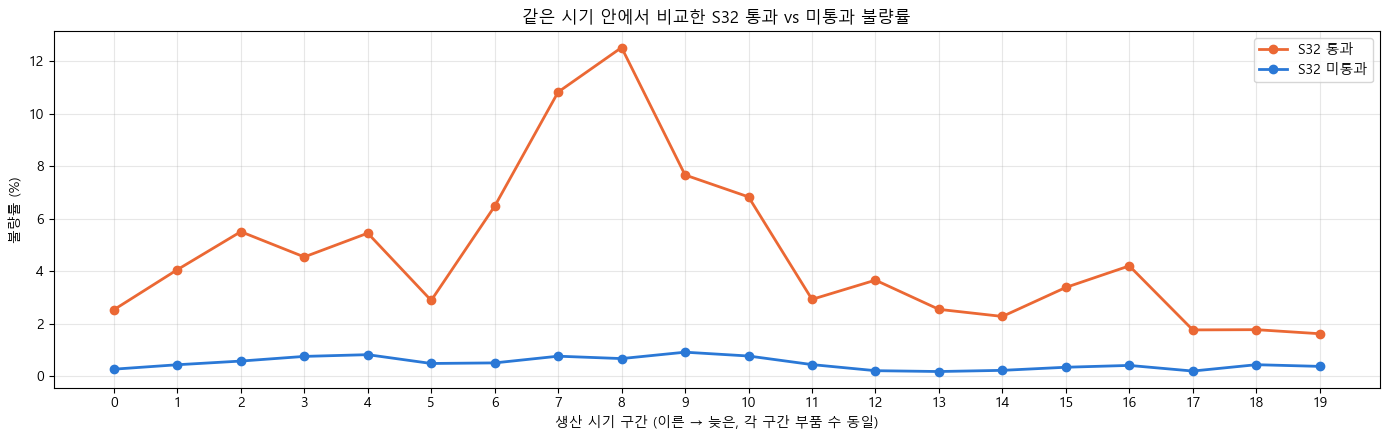

In [9]:
# ── 셀 8: 시기 효과 확인 — S32가 "불량이 많던 시기"에만 쓰인 건 아닌가 ──
# 만약 S32가 공정 전체가 불안정하던 특정 기간에 주로 쓰였다면,
# S32 불량률이 높은 건 S32 탓이 아니라 그 "시기" 탓일 수 있음
# → 생산 시기를 20구간으로 나눠, 같은 시기 안에서 S32 통과 vs 미통과를 비교
tcols = [c for c in st_time.columns if c != 'Id']
part_time = np.nanmin(st_time[tcols].values, axis=1)        # 부품이 라인에 처음 들어온 시각
ok = ~np.isnan(part_time)
df_t = pd.DataFrame({
    't': part_time[ok],
    's32': (passed[TARGET] == 1).values[ok],
    'y': passed['Response'].values[ok],
})
df_t['구간'] = pd.qcut(df_t['t'], 20, labels=False, duplicates='drop')

rows = []
for b, g in df_t.groupby('구간'):
    g1, g0 = g[g['s32']], g[~g['s32']]
    rows.append({'시기 구간': b, '부품 수': len(g), 'S32 사용 비율': g['s32'].mean(),
                 '전체 불량률': g['y'].mean(),
                 'S32 통과 불량률': g1['y'].mean() if len(g1) else np.nan,
                 'S32 미통과 불량률': g0['y'].mean(),
                 'S32 통과 부품': len(g1)})
tt = pd.DataFrame(rows)
tt['배수'] = tt['S32 통과 불량률'] / tt['S32 미통과 불량률']

# 시기를 맞춘 평균 배수 (Mantel-Haenszel 위험비): 구간별 비교를 하나의 숫자로 합침
num = den = 0.0
for _, g in df_t.groupby('구간'):
    n, n1 = len(g), g['s32'].sum()
    a = g.loc[g['s32'], 'y'].sum()
    c = g.loc[~g['s32'], 'y'].sum()
    num += a * (n - n1) / n
    den += c * n1 / n
crude = df_t.loc[df_t['s32'], 'y'].mean() / df_t.loc[~df_t['s32'], 'y'].mean()

print(f'시기 무시한 배수: {crude:.1f}배')
print(f'시기를 맞춘 배수: {num/den:.1f}배')
print(f"S32 배수가 2배 이상인 시기 구간: {(tt['배수'] >= 2).sum()}개 / {len(tt)}개")
print(f"구간별 전체 불량률 범위: {tt['전체 불량률'].min():.2%} ~ {tt['전체 불량률'].max():.2%}")
print()
fmt = {c: '{:.2%}'.format for c in ['S32 사용 비율', '전체 불량률', 'S32 통과 불량률', 'S32 미통과 불량률']}
fmt['배수'] = '{:.1f}'.format
print(tt.to_string(index=False, formatters=fmt))

# 그래프: 시기별 S32 통과/미통과 불량률
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(tt['시기 구간'], tt['S32 통과 불량률'] * 100, color='#eb6834', marker='o', linewidth=2, label='S32 통과')
ax.plot(tt['시기 구간'], tt['S32 미통과 불량률'] * 100, color='#2a78d6', marker='o', linewidth=2, label='S32 미통과')
ax.set_xlabel('생산 시기 구간 (이른 → 늦은, 각 구간 부품 수 동일)')
ax.set_ylabel('불량률 (%)')
ax.set_title('같은 시기 안에서 비교한 S32 통과 vs 미통과 불량률')
ax.set_xticks(tt['시기 구간'])
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()